# NMR

In [2]:
import mcphysics
import spinmob as s
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

import nmr

## Calculating T2

In [3]:
%matplotlib inline

sns.set_theme(
    "paper",
    "ticks",
    font="Helvetica"
)

### Loading Data

In [4]:
data_dict = {
    "glycerine": nmr.load_data("t2_glycerin"),
    "oil": nmr.load_data("t2_oil"),
    "heavy_oil": nmr.load_data("t2_heavy_oil"),
    "snot": nmr.load_data("t2_snot")
}

pulses_dict = {
    "glycerine": {
        "n_pulses": 20,
        "min_height": 0.5,
        "max_points": 6
    },
    "oil": {
        "n_pulses": 30,
        "min_height": 0.3,
        "max_points": 11
    },
    "heavy_oil": {
        "n_pulses": 6,
        "min_height": 0.5,
        "max_points": 5
    },
    "snot": {
        "n_pulses": 12,
        "min_height": 0.2,
        "max_points": 5
    },
}

In [5]:
limits = {
    key: nmr.detect_resolution(value)
    for key, value in data_dict.items()
}
print(limits["oil"])

0.1171875


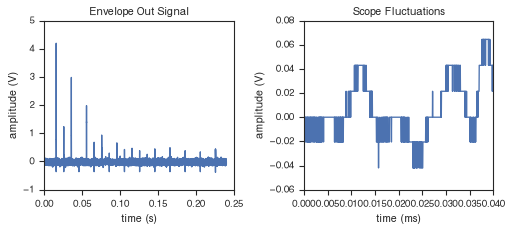

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(6.5, 3))
data = data_dict["snot"][0]

ax[0].plot(data[0], data[1])
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel("amplitude (V)")
ax[0].set_xlim([0, 0.25])
ax[0].set_title("Envelope Out Signal")

ax[1].plot(data[0][:1000] * 1e3, data[1][:1000])
ax[1].set_xlabel("time (ms)")
ax[1].set_ylabel("amplitude (V)")
ax[1].set_title("Scope Fluctuations")

fig.tight_layout()
plt.savefig("figure_1.png", dpi=600,)
plt.show()

### Data Analysis

In [7]:
# Find peaks
peak_points_dict = {
    key: nmr.find_peaks(value, **pulses_dict[key])
    for key, value in data_dict.items()
}
print(peak_points_dict["snot"])

(2, 6)
(2, 6)
(2, 6)
(2, 11)
(2, 11)
(2, 11)
(2, 5)
(2, 5)
(2, 5)
(2, 5)
(2, 5)
(2, 5)
[array([[0.        , 0.01999936, 0.03999984, 0.0599992 , 0.08000272],
       [2.98242188, 1.98144531, 0.93774414, 0.66064453, 0.46923828]]), array([[0.        , 0.01999664, 0.03999804, 0.05999872, 0.07999472],
       [2.93945312, 1.87451172, 0.95849609, 0.72412109, 0.38330078]]), array([[0.        , 0.019995  , 0.03999664, 0.05999552, 0.07999424],
       [3.08886719, 1.95947266, 0.97973633, 0.66015625, 0.38330078]])]


In [8]:
plot_dict = {
    key: nmr.get_plot_vals(peak_points_dict[key], limits[key])
    for key in data_dict
}

In [9]:
model_dict = {
    key: nmr.fit_t2_model(plot_dict[key]) for key in data_dict
}

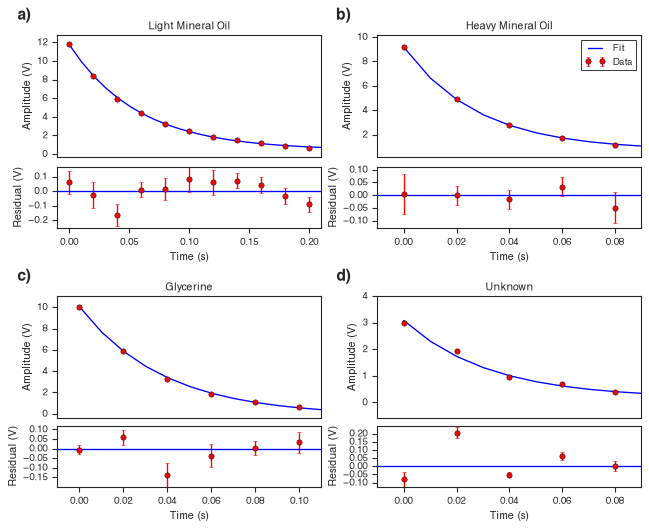

In [10]:
keys = ["oil", "heavy_oil", "glycerine", "snot"]
titles = ["Light Mineral Oil", "Heavy Mineral Oil", "Glycerine", "Unknown"]

model = lambda t, M_0, T_2, b: M_0 * np.exp(-t / T_2) + b
space = np.linspace(0, 1, 100)
fig, ax = plt.subplots(4, 2, figsize=(8, 6.5), height_ratios=(2, 1, 2, 1), layout="compressed")

axes = ax.flatten()
big_plots = [0, 1, 4, 5]
little_plots = [2, 3, 6, 7]
letters = ["a", "b", "c", "d"]

for i in range(len(keys)):
    fit = model_dict[keys[i]]
    times = plot_dict[keys[i]]["times"]
    means = plot_dict[keys[i]]["means"]
    uncertainties = plot_dict[keys[i]]["uncertainties"]
    vals = model(space, *fit[0])

    axes[big_plots[i]].plot(space, vals, color="blue", label="Fit")
    axes[big_plots[i]].errorbar(times, means, yerr=uncertainties, fmt='o', color="red", capsize=2, label="Data")
    axes[big_plots[i]].set_xlim([np.min(times) - 0.01, np.max(times) + 0.01])
    axes[big_plots[i]].set_ylim([np.min(means) - 1, np.max(means) + 1])
    axes[big_plots[i]].set_ylabel("Amplitude (V)")
    axes[big_plots[i]].set_title(titles[i])
    axes[big_plots[i]].set_xticks([])
    axes[big_plots[i]].text(-0.1, 1.1, letters[i] + ")", transform=axes[big_plots[i]].transAxes, fontsize=14, fontweight='bold', ha='right', va='bottom')
    if i == 1:
        axes[big_plots[i]].legend()

    residuals = means - model(times, *fit[0])
    plot_dict[keys[i]]["residuals"] = residuals
    axes[little_plots[i]].errorbar(times, residuals, yerr=uncertainties, fmt='o', color="red", capsize=2)
    axes[little_plots[i]].axhline(0, color="blue")
    axes[little_plots[i]].set_xlim([np.min(times) - 0.01, np.max(times) + 0.01])
    axes[little_plots[i]].set_ylim([np.min(residuals) - np.max(uncertainties), np.max(residuals) + np.max(uncertainties)])
    axes[little_plots[i]].set_xlabel("Time (s)")
    axes[little_plots[i]].set_ylabel("Residual (V)")

    # fig.tight_layout()
    plt.savefig("figure_2.png", dpi=600)

In [11]:
for key in model_dict:
    print(key)
    fit = model_dict[key]
    residuals = plot_dict[key]["residuals"]
    uncertainties = plot_dict[key]["uncertainties"]
    perr = np.sqrt(np.diag(fit[1]))
    chi_squared = np.sum((residuals / uncertainties)**2)
    p = sp.stats.chi2.sf(chi_squared, len(residuals) - 3)
    print("t_2", fit[0][1], perr[1])
    print("Raw chi^2:", chi_squared)
    print("Adjusted chi^2:", chi_squared / (len(times) - 3))
    print("p:", p)



glycerine
t_2 0.0380898821919189 0.0006675520556731146
Raw chi^2: 8.235001250811564
Adjusted chi^2: 4.117500625405782
p: 0.04139658558755594
oil
t_2 0.05743698397715288 0.0009192239828609889
Raw chi^2: 12.503302424878566
Adjusted chi^2: 6.251651212439283
p: 0.13012070703575768
heavy_oil
t_2 0.028293704797732633 0.0007219785637260589
Raw chi^2: 1.5937396356122582
Adjusted chi^2: 0.7968698178061291
p: 0.45073764921019344
snot
t_2 0.032235798497542524 0.0014137237707850165
Raw chi^2: 63.5343485696157
Adjusted chi^2: 31.76717428480785
p: 1.5984221990476586e-14


### Methods Figure

## Calculating T1

In [12]:
t1_data = nmr.load_data_t1("t1.csv")

In [13]:
for key in t1_data:
    print(t1_data[key][2])
    # t1_data[key][2] /= np.sqrt(12)

model = lambda tau, M_0, T_1, c: M_0 * (1 - np.exp(-tau / T_1)) + c
fit_dict = {}

for key in t1_data:
    print(key)
    fit = sp.optimize.curve_fit(
        model,
        t1_data[key][0],
        t1_data[key][1],
        sigma=t1_data[key][2],
        absolute_sigma=True,
        p0 = (2000, 0.05, 0)
    )
    fit_dict[key] = fit

print(fit_dict["oil"])

[ 8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8. 10. 10. 10. 10.]
[ 8.  8.  8.  2.  2.  2.  2.  2.  8.  8. 10. 10. 20. 20. 20. 20. 20.]
[10. 10.  8.  4.  2.  2.  2.  4.  4.  4.  8.  8.  8. 20. 20. 20. 20.]
oil
heavy_oil
glycerin
(array([ 2.57069846e+03,  5.60388520e-02, -1.06775936e+03]), array([[ 7.13039209e+01,  1.20848507e-03, -2.16581718e+01],
       [ 1.20848507e-03,  2.44797304e-07,  2.46226102e-03],
       [-2.16581718e+01,  2.46226102e-03,  4.63785362e+01]]))


[ 8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8. 10. 10. 10. 10.]
[ 8.  8.  8.  2.  2.  2.  2.  2.  8.  8. 10. 10. 20. 20. 20. 20. 20.]
[10. 10.  8.  4.  2.  2.  2.  4.  4.  4.  8.  8.  8. 20. 20. 20. 20.]


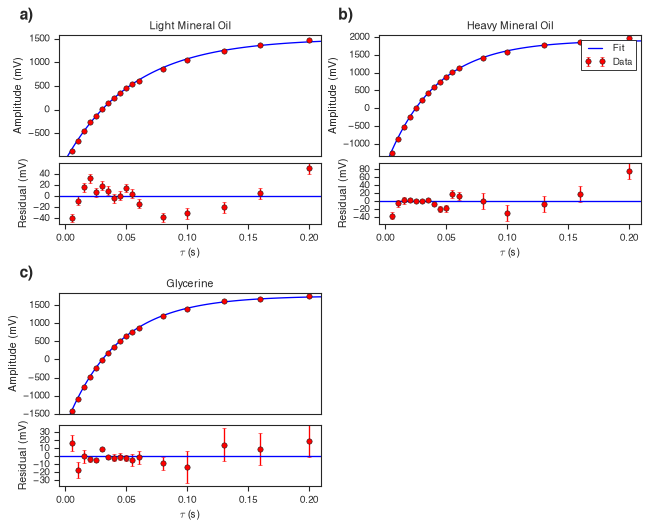

In [14]:
keys = ["oil", "heavy_oil", "glycerin"]
titles = ["Light Mineral Oil", "Heavy Mineral Oil", "Glycerine"]
res_dict = {}

space = np.linspace(0, 0.25, 100)
fig, ax = plt.subplots(4, 2, figsize=(8, 6.5), height_ratios=(2, 1, 2, 1), layout="compressed")

axes = ax.flatten()
big_plots = [0, 1, 4]
little_plots = [2, 3, 6]
letters = ["a", "b", "c"]

for i in range(len(keys)):
    fit = fit_dict[keys[i]]
    times = t1_data[keys[i]][0]
    means = t1_data[keys[i]][1]
    uncertainties = t1_data[keys[i]][2]
    print(uncertainties)
    vals = model(space, *fit[0])

    axes[big_plots[i]].plot(space, vals, color="blue", label="Fit")
    axes[big_plots[i]].errorbar(times, means, yerr=uncertainties, fmt='o', color="red", capsize=2, label="Data")
    axes[big_plots[i]].set_xlim([np.min(times) - 0.01, np.max(times) + 0.01])
    axes[big_plots[i]].set_ylim([np.min(means) - 100, np.max(means) + 100])
    axes[big_plots[i]].set_ylabel("Amplitude (mV)")
    axes[big_plots[i]].set_title(titles[i])
    axes[big_plots[i]].set_xticks([])
    axes[big_plots[i]].text(-0.1, 1.1, letters[i] + ")", transform=axes[big_plots[i]].transAxes, fontsize=14, fontweight='bold', ha='right', va='bottom')
    if i == 1:
        axes[big_plots[i]].legend()

    residuals = means - model(times, *fit[0])
    res_dict[keys[i]] = residuals
    axes[little_plots[i]].errorbar(times, residuals, yerr=uncertainties, fmt='o', color="red", capsize=2)
    axes[little_plots[i]].axhline(0, color="blue")
    axes[little_plots[i]].set_xlim([np.min(times) - 0.01, np.max(times) + 0.01])
    axes[little_plots[i]].set_ylim([np.min(residuals) - np.max(uncertainties), np.max(residuals) + np.max(uncertainties)])
    axes[little_plots[i]].set_xlabel(r"$\tau$ (s)")
    axes[little_plots[i]].set_ylabel("Residual (mV)")

axes[5].set_axis_off()
axes[7].set_axis_off()

# fig.tight_layout()
plt.savefig("figure_3.png", dpi=600)

In [15]:
for key in fit_dict:
    print(key)
    fit = fit_dict[key]
    residuals = res_dict[key]
    uncertainties = t1_data[key][2]
    perr = np.sqrt(np.diag(fit[1]))
    chi_squared = np.sum((residuals / uncertainties)**2)
    p = sp.stats.chi2.sf(chi_squared, len(residuals) - 3)
    print("t_1", fit[0][1], perr[1])
    print("Raw chi^2:", chi_squared)
    print("Adjusted chi^2:", chi_squared / (len(times) - 3))
    print("p:", p)

oil
t_1 0.05603885195847177 0.0004947699505210481
Raw chi^2: 121.45481616205922
Adjusted chi^2: 8.675344011575659
p: 3.263935588792009e-19
heavy_oil
t_1 0.040454126041017086 0.0002731091192753582
Raw chi^2: 72.07958915413704
Adjusted chi^2: 5.14854208243836
p: 8.08887305315181e-10
glycerin
t_1 0.04251483263848222 0.00029476688836805606
Raw chi^2: 35.209910301391204
Adjusted chi^2: 2.5149935929565146
p: 0.0013684323085721153


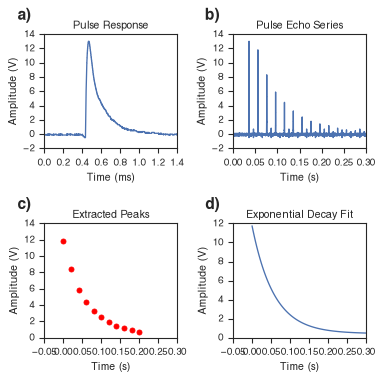

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(4.875, 4.875))

data = data_dict["oil"][0]

ax[0, 0].plot(data[0][178000:185000] * 1e3 - 35.6, data[1][178000:185000])
ax[0, 0].set_xlabel("Time (ms)")
ax[0, 0].set_ylabel("Amplitude (V)")
ax[0, 0].set_title("Pulse Response")
ax[0, 0].text(-0.1, 1.1, "a)", transform=ax[0, 0].transAxes, fontsize=14, fontweight='bold', ha='right', va='bottom')


ax[0, 1].plot(data[0], data[1])
ax[0, 1].set_xlabel("Time (s)")
ax[0, 1].set_ylabel("Amplitude (V)")
ax[0, 1].set_xlim([0, 0.3])
ax[0, 1].set_title("Pulse Echo Series")
ax[0, 1].text(-0.1, 1.1, "b)", transform=ax[0, 1].transAxes, fontsize=14, fontweight='bold', ha='right', va='bottom')

times = plot_dict["oil"]["times"]
means = plot_dict["oil"]["means"]
ax[1, 0].scatter(times, means, color="red")
ax[1, 0].set_xlim([-0.05, 0.3])
ax[1, 0].set_xlabel("Time (s)")
ax[1, 0].set_ylabel("Amplitude (V)")
ax[1, 0].set_title("Extracted Peaks")
ax[1, 0].text(-0.1, 1.1, "c)", transform=ax[1, 0].transAxes, fontsize=14, fontweight='bold', ha='right', va='bottom')

space = np.linspace(0, 0.3, 100)
fit = model_dict["oil"]
model = lambda t, M_0, T_2, b: M_0 * np.exp(-t / T_2) + b
ax[1, 1].set_xlim([-0.05, 0.3])
ax[1, 1].set_xlabel("Time (s)")
ax[1, 1].set_ylabel("Amplitude (V)")
ax[1, 1].set_title("Exponential Decay Fit")
ax[1, 1].text(-0.1, 1.1, "d)", transform=ax[1, 1].transAxes, fontsize=14, fontweight='bold', ha='right', va='bottom')

vals = model(space, *fit[0])
ax[1, 1].plot(space, vals)

fig.tight_layout()
plt.savefig("figure_4.png", dpi=600)